# 🛡️ Phát hiện Payload XSS/SQLi bị Obfuscate bằng Deep Learning
## CNN + LSTM Hybrid Model Pipeline

---
**Phiên bản:** 2.0 (Fixed - Đã sửa các vấn đề tiền xử lý)  
**Kiến trúc:** CNN (Multi-kernel) + Bidirectional LSTM → Concatenate → Dense → Sigmoid

---
## ⚠️ AUDIT TIỀN XỬ LÝ - CÁC VẤN ĐỀ PHÁT HIỆN

| # | Vấn đề | Mức độ | Nguyên nhân | Fix |
|---|--------|--------|-------------|-----|
| 1 | **DATA LEAK qua Tokenizer** | 🔴 Nghiêm trọng | `tokenizer.fit_on_texts(df)` fit trên toàn bộ dataset trước khi split → vocabulary index bị "nhiễm" thông tin từ test set | Fit tokenizer CHỈ trên `X_train` sau khi split |
| 2 | **Thiếu Validation Set** | 🔴 Nghiêm trọng | Chỉ có train/test → không monitor được overfitting trong quá trình train | Dùng `train_test_split` 2 lần hoặc `validation_split` |
| 3 | **MAX_LEN chưa có cơ sở** | 🟡 Trung bình | MAX_LEN=200 đặt tùy ý, chưa phân tích phân phối độ dài thực tế | Phân tích percentile 95/99 để chọn MAX_LEN hợp lý |
| 4 | **Leading whitespace ở CSIC** | 🟡 Trung bình | `content.fillna("") + " " + URL` → khi content=NaN tạo ra `" URL"` | Dùng `.strip()` hoặc join có điều kiện |
| 5 | **Không lưu tokenizer** | 🟠 Nhỏ | Tokenizer chỉ tồn tại trong RAM → không thể dùng lại lúc inference | Lưu bằng `pickle` hoặc `joblib` |


## 0. Thiết lập môi trường chạy trên VS Code

In [20]:
from pathlib import Path

# VS Code/Jupyter chạy notebook với thư mục làm việc hiện tại.
# Đặt notebook và hai file CSV trong cùng một thư mục.
PROJECT_DIR = Path.cwd().resolve()
DATA_DIR = PROJECT_DIR
if not (DATA_DIR / 'SQLInjection_XSS_MixDataset.1.0.0.csv').is_file():
    DATA_DIR = PROJECT_DIR.parent

MIX_DATA_PATH = DATA_DIR / "SQLInjection_XSS_MixDataset.1.0.0.csv"
CSIC_DATA_PATH = DATA_DIR / "csic_database.csv"

required_files = [MIX_DATA_PATH, CSIC_DATA_PATH]
missing_files = [path.name for path in required_files if not path.is_file()]

if missing_files:
    raise FileNotFoundError(
        f"Không tìm thấy {missing_files} trong thư mục: {DATA_DIR}\n"
        "Hãy mở đúng thư mục dự án trong VS Code hoặc sửa DATA_DIR."
    )

print(f"Project directory: {PROJECT_DIR}")
print("Đã tìm thấy đầy đủ các file dữ liệu.")

Project directory: C:\Users\admin\Desktop\chal
Đã tìm thấy đầy đủ các file dữ liệu.


In [21]:
#%pip install pandas numpy matplotlib seaborn scikit-learn tensorflow

In [22]:
import pandas as pd
import numpy as np
import re
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from urllib.parse import unquote
import html

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve, auc
)

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Embedding, Conv1D, MaxPooling1D, GlobalMaxPooling1D,
    LSTM, Dense, Dropout, BatchNormalization, Concatenate
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.regularizers import l2
from tensorflow.keras import backend as K

# Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {len(tf.config.list_physical_devices('GPU')) > 0}")

TensorFlow version: 2.21.0
GPU available: False


## 1. Thu thập và Tích hợp Dữ liệu

In [23]:
# --- Dataset 1: Kaggle SQLi + XSS ---
df1 = pd.read_csv(MIX_DATA_PATH)
print("Kaggle dataset shape:", df1.shape)
print(df1.head(3))

Kaggle dataset shape: (156636, 4)
                                            Sentence  SQLInjection  XSS  \
0                      " or pg_sleep ( __TIME__ ) --           1.0  0.0   
1  create user name identified by pass123 tempora...           1.0  0.0   
2                                                %29           1.0  0.0   

   Normal  
0     0.0  
1     0.0  
2     0.0  


In [24]:
# --- Dataset 2: CSIC 2010 ---
df2 = pd.read_csv(CSIC_DATA_PATH)
print("CSIC dataset shape:", df2.shape)
print(df2.head(3))

CSIC dataset shape: (61065, 17)
  Unnamed: 0 Method                                         User-Agent  \
0     Normal    GET  Mozilla/5.0 (compatible; Konqueror/3.5; Linux)...   
1     Normal    GET  Mozilla/5.0 (compatible; Konqueror/3.5; Linux)...   
2     Normal   POST  Mozilla/5.0 (compatible; Konqueror/3.5; Linux)...   

     Pragma Cache-Control                                             Accept  \
0  no-cache      no-cache  text/xml,application/xml,application/xhtml+xml...   
1  no-cache      no-cache  text/xml,application/xml,application/xhtml+xml...   
2  no-cache      no-cache  text/xml,application/xml,application/xhtml+xml...   

                    Accept-encoding               Accept-charset language  \
0  x-gzip, x-deflate, gzip, deflate  utf-8, utf-8;q=0.5, *;q=0.5       en   
1  x-gzip, x-deflate, gzip, deflate  utf-8, utf-8;q=0.5, *;q=0.5       en   
2  x-gzip, x-deflate, gzip, deflate  utf-8, utf-8;q=0.5, *;q=0.5       en   

             host                        

In [25]:
# --- Chuẩn hóa df1 (Kaggle) ---
df1 = df1.rename(columns={'Sentence': 'payload'})
df1['label'] = df1[['SQLInjection', 'XSS']].max(axis=1).astype(int)
df1 = df1[['payload', 'label']]
df1['payload'] = df1['payload'].astype(str)

print("df1 label distribution:")
print(df1['label'].value_counts())

df1 label distribution:
label
1    98115
0    58521
Name: count, dtype: int64


In [26]:
# --- Chuẩn hóa df2 (CSIC) ---
# FIX: Tránh leading whitespace khi content rỗng
def build_csic_payload(row):
    parts = []
    if pd.notna(row.get('content')) and str(row['content']).strip():
        parts.append(str(row['content']).strip())
    if pd.notna(row.get('URL')) and str(row['URL']).strip():
        parts.append(str(row['URL']).strip())
    return ' '.join(parts)

df2['payload'] = df2.apply(build_csic_payload, axis=1)
df2['label'] = df2['classification'].astype(int)
df2 = df2[['payload', 'label']]

print("df2 label distribution:")
print(df2['label'].value_counts())

df2 label distribution:
label
0    36000
1    25065
Name: count, dtype: int64


In [27]:
# --- Tích hợp ---
df = pd.concat([df1, df2], ignore_index=True)
df = df.sample(frac=1, random_state=SEED).reset_index(drop=True)
print(f"Total samples: {df.shape[0]}")
print(df['label'].value_counts())

Total samples: 217701
label
1    123180
0     94521
Name: count, dtype: int64


## 2. Tiền xử lý Dữ liệu

In [28]:
"""
Pipeline tiền xử lý dữ liệu cho mô hình CNN-LSTM
phát hiện SQLi và XSS (bao gồm payload bị obfuscated)

Thiết kế:
- Giữ nguyên encoding (URL encoding, HTML entity) để mô hình
  học được pattern obfuscation từ dữ liệu
- Giữ nguyên case (không lowercase) để mô hình phân biệt
  được case variation — một kỹ thuật obfuscation phổ biến
- Chỉ chuẩn hoá whitespace để tránh nhiễu không có nghĩa ngữ nghĩa
- Split TRƯỚC khi fit Tokenizer để tránh data leakage
"""

import pandas as pd
import numpy as np
import re
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

# ─────────────────────────────────────────────
# 1. LOAD DỮ LIỆU
# ─────────────────────────────────────────────

df1 = pd.read_csv(MIX_DATA_PATH)
df1.head()

df2 = pd.read_csv(CSIC_DATA_PATH)
df2.head()

# Chuẩn hóa tên cột
df1 = df1.rename(columns={'Sentence': 'payload'})

# Chuyển đổi nhãn One-Hot thành nhãn nhị phân (0 = Normal, 1 = Attack)
df1['label'] = df1[['SQLInjection', 'XSS']].max(axis=1)

# Trích xuất các trường cần thiết
df1 = df1[['payload', 'label']]

df1['payload'] = df1['payload'].astype(str)
df1['label'] = df1['label'].astype(int)
df1.head()

df2["payload"] = (
    df2[["content", "URL"]]
    .fillna("")
    .astype(str)
    .agg(" ".join, axis=1)
    .str.strip()
)

# classification: 0 = normal, 1 = attack
df2["label"] = df2["classification"].astype(int)

df2 = df2[["payload", "label"]]
df2.head()

# ─────────────────────────────────────────────
# 2. TIỀN XỬ LÝ VĂN BẢN
# ─────────────────────────────────────────────

def normalize_payload(p: str) -> str:
    """
    Chuẩn hoá payload đầu vào.

    Quyết định thiết kế:
    - KHÔNG decode URL encoding (%XX) và HTML entity (&#x):
      mô hình cần học nhận ra các pattern mã hoá này như
      đặc trưng của obfuscation, không phải payload đã giải mã
    - KHÔNG lowercase: case variation (SeLeCt, <sCrIpT>) là
      kỹ thuật bypass phổ biến — giữ case giúp mô hình học
      được tín hiệu này
    - CHỈ chuẩn hoá whitespace: khoảng trắng thừa không mang
      thông tin ngữ nghĩa, chuẩn hoá để tránh nhiễu
    """
    if not isinstance(p, str):
        return ""
    p = re.sub(r'\s+', ' ', p).strip()
    return p

# Gộp 2 tập
df = pd.concat([df1, df2], ignore_index=True)

# Áp dụng normalize
df["payload"] = df["payload"].apply(normalize_payload)
df["label"] = df["label"].astype(int)

# Loại payload rỗng và payload có nhãn mâu thuẫn.
df = df[df["payload"].str.len() > 0].copy()
label_count = df.groupby("payload")["label"].transform("nunique")
conflicting_payloads = df.loc[label_count > 1, "payload"].nunique()
df = df[label_count == 1]

# Mỗi payload chỉ xuất hiện một lần để tránh rò rỉ giữa các tập.
df = df.drop_duplicates(subset=["payload"]).reset_index(drop=True)

# Shuffle
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print("=== THỐNG KÊ SAU TIỀN XỬ LÝ ===")
print(f"Payload mâu thuẫn đã loại: {conflicting_payloads:,}")
print(f"Tổng số mẫu : {len(df):,}")
print(f"Phân phối nhãn:\n{df['label'].value_counts()}")
print(f"\nĐộ dài payload (ký tự):")
lengths = df["payload"].str.len()
print(f"  Trung bình : {lengths.mean():.1f}")
print(f"  Trung vị   : {lengths.median():.1f}")
print(f"  p90        : {lengths.quantile(0.90):.0f}")
print(f"  p95        : {lengths.quantile(0.95):.0f}")
print(f"  p99        : {lengths.quantile(0.99):.0f}")
print(f"  Max        : {lengths.max():.0f}")

# ─────────────────────────────────────────────
# 3. TRAIN / TEST SPLIT — TRƯỚC KHI FIT TOKENIZER
# ─────────────────────────────────────────────
# stratify=df["label"] đảm bảo tỉ lệ nhãn trong train và test
# giống nhau — quan trọng khi phân phối nhãn không đều

X_train_text, X_temp_text, y_train, y_temp = train_test_split(
    df["payload"],
    df["label"],
    test_size=0.30,
    random_state=42,
    stratify=df["label"]
)

X_val_text, X_test_text, y_val, y_test = train_test_split(
    X_temp_text,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print(f"\n=== PHÂN CHIA DỮ LIỆU ===")
print(f"Train: {len(X_train_text):,} mẫu")
print(f"Val  : {len(X_val_text):,} mẫu")
print(f"Test : {len(X_test_text):,} mẫu")

# ─────────────────────────────────────────────
# 4. TOKENIZATION — FIT CHỈ TRÊN TRAIN
# ─────────────────────────────────────────────
# char_level=True : mỗi ký tự là một token
# lower=False     : giữ nguyên case, nhất quán với normalize_payload
# filters=None    : không lọc bỏ ký tự nào — ký tự đặc biệt như
#                   %, <, >, ', " đều là đặc trưng quan trọng
# oov_token="<OOV>": xử lý ký tự chưa thấy trong train

tokenizer = Tokenizer(
    char_level=True,
    lower=False,
    filters=None,
    oov_token="<OOV>"
)

# Fit CHỈ trên tập train để tránh data leakage
tokenizer.fit_on_texts(X_train_text)

VOCAB_SIZE = len(tokenizer.word_index) + 1  # +1 cho padding index 0
print(f"\n=== TOKENIZER ===")
print(f"Vocab size (số ký tự unique): {VOCAB_SIZE}")

# ─────────────────────────────────────────────
# 5. PADDING
# ─────────────────────────────────────────────
# Chỉ dùng độ dài của tập train để chọn MAX_LEN, tránh data leakage.
# Giới hạn 512 để nhánh LSTM không tốn quá nhiều bộ nhớ và thời gian.
# truncating="post": cắt ở cuối — giữ nguyên phần đầu payload
# nơi thường chứa keyword tấn công quan trọng hơn
# padding="post"  : pad 0 ở cuối — không ảnh hưởng Conv1D
#                   vì kernel đọc từ đầu chuỗi

train_lengths = X_train_text.str.len()
estimated_max_len = int(np.ceil(train_lengths.quantile(0.95) / 32) * 32)
MAX_LEN = min(512, max(200, estimated_max_len))
print(f"MAX_LEN: {MAX_LEN}")

X_train = pad_sequences(
    tokenizer.texts_to_sequences(X_train_text),
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

X_val = pad_sequences(
    tokenizer.texts_to_sequences(X_val_text),
    maxlen=MAX_LEN, 
    padding="post", 
    truncating="post"
)

X_test = pad_sequences(
    tokenizer.texts_to_sequences(X_test_text),
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

y_train = y_train.values
y_val   = y_val.values
y_test  = y_test.values

print(f"\n=== SHAPE ĐẦU VÀO MÔ HÌNH ===")
print(f"X_train : {X_train.shape}")
print(f"X_val   : {X_val.shape}")
print(f"X_test  : {X_test.shape}")
print(f"y_train : {y_train.shape}")
print(f"y_val   : {y_val.shape}")
print(f"y_test  : {y_test.shape}")

# ─────────────────────────────────────────────
# 6. XỬ LÝ MẤT CÂN BẰNG NHÃN
# ─────────────────────────────────────────────
# Phân phối nhãn sau gộp: Attack ~64%, Normal ~36%
# class_weight điều chỉnh loss function để mô hình
# không bị thiên về lớp đa số

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(zip(np.unique(y_train), class_weights))

print(f"\n=== CLASS WEIGHT ===")
print(f"Normal (0): {class_weight_dict[0]:.4f}")
print(f"Attack (1): {class_weight_dict[1]:.4f}")
print("\nTruyền vào model.fit(..., class_weight=class_weight_dict)")

=== THỐNG KÊ SAU TIỀN XỬ LÝ ===
Payload mâu thuẫn đã loại: 30
Tổng số mẫu : 177,217
Phân phối nhãn:
label
1    113923
0     63294
Name: count, dtype: int64

Độ dài payload (ký tự):
  Trung bình : 333.4
  Trung vị   : 251.0
  p90        : 784
  p95        : 883
  p99        : 975
  Max        : 8493

=== PHÂN CHIA DỮ LIỆU ===
Train: 124,051 mẫu
Val  : 26,583 mẫu
Test : 26,583 mẫu

=== TOKENIZER ===
Vocab size (số ký tự unique): 185
MAX_LEN: 512

=== SHAPE ĐẦU VÀO MÔ HÌNH ===
X_train : (124051, 512)
X_val   : (26583, 512)
X_test  : (26583, 512)
y_train : (124051,)
y_val   : (26583,)
y_test  : (26583,)

=== CLASS WEIGHT ===
Normal (0): 1.4000
Attack (1): 0.7778

Truyền vào model.fit(..., class_weight=class_weight_dict)


## 3. Xây dựng mô hình CNN-LSTM lai

Mô hình dùng **Keras Functional API** để tách output của Embedding thành hai nhánh chạy song song độc lập:

- **Embedding 64 chiều:** đủ biểu diễn quan hệ giữa khoảng 185 ký tự nhưng vẫn gọn hơn các embedding lớn thường dùng cho word-level.
- **Nhánh CNN tuần tự:** ba lớp Conv1D có kernel `3 → 4 → 5`, học dần mẫu ký tự cục bộ từ ngắn đến dài. Số filter `128 → 128 → 64` ưu tiên khả năng trích xuất nhiều mẫu ở đầu nhánh, rồi nén biểu diễn trước GlobalMaxPooling.
- **`padding='same'`, pool size 2:** giữ thông tin biên trước khi mỗi lần pooling giảm một nửa chiều thời gian. Sau ba lần pooling, chuỗi 512 ký tự còn khoảng 64 bước.
- **Dropout CNN 0.25:** regularization mức vừa phải, tránh làm mất quá nhiều tín hiệu ký tự hiếm.
- **Nhánh LSTM một chiều `32 → 16` units:** đúng theo sơ đồ; LSTM đầu trả toàn bộ chuỗi cho LSTM sau, LSTM sau trả vector cuối. Đây **không phải Bidirectional LSTM**; nếu tiêu đề hoặc phần mô tả khác ghi Bidirectional thì cần sửa để nhất quán với kiến trúc thực nghiệm.
- **Dropout LSTM 0.20, recurrent dropout 0.10, L2 = 1e-4:** hạn chế overfit ở cả input, trạng thái hồi quy và trọng số kernel. `recurrent_dropout` có thể làm huấn luyện chậm hơn trên một số GPU nhưng được giữ ở mức thấp theo yêu cầu regularization của sơ đồ.
- **Dense 64 units + ReLU + BatchNorm:** hợp nhất vector đặc trưng nhưng không tạo tầng phân loại quá lớn so với bài toán nhị phân.

> Lưu ý từ review Giai đoạn 1: `MAX_LEN=512` làm truncate khoảng 26.5% mẫu trong dữ liệu hiện tại. Kiến trúc dưới đây tôn trọng pipeline đã duyệt; cần ghi hạn chế này trong báo cáo và có thể làm ablation với 768/896 ở thí nghiệm sau.


In [36]:
# Các hyperparameter kiến trúc đã được giải thích trong markdown phía trên
EMBEDDING_DIM = 64
CNN_FILTERS = (128, 128, 64)
CNN_KERNELS = (3, 4, 5)
POOL_SIZE = 2
CNN_DROPOUT = 0.25
LSTM_DROPOUT = 0.20
LSTM_RECURRENT_DROPOUT = 0.10
L2_FACTOR = 1e-4
DENSE_UNITS = 64

inputs = Input(shape=(MAX_LEN,), dtype="int32", name="char_input")
embedded = Embedding(
    input_dim=VOCAB_SIZE,
    output_dim=EMBEDDING_DIM,
    name="char_embedding"
)(inputs)

# Nhánh CNN: các block chạy tuần tự trên cùng một nhánh
cnn = embedded
for block_id, (filters, kernel_size) in enumerate(
    zip(CNN_FILTERS, CNN_KERNELS), start=1
):
    cnn = Conv1D(
        filters=filters,
        kernel_size=kernel_size,
        padding="same",
        activation="relu",
        kernel_regularizer=l2(L2_FACTOR),
        name=f"cnn_conv_{block_id}_k{kernel_size}"
    )(cnn)
    cnn = BatchNormalization(name=f"cnn_bn_{block_id}")(cnn)
    cnn = MaxPooling1D(
        pool_size=POOL_SIZE,
        name=f"cnn_pool_{block_id}"
    )(cnn)
    cnn = Dropout(CNN_DROPOUT, name=f"cnn_dropout_{block_id}")(cnn)

cnn_vector = GlobalMaxPooling1D(name="cnn_global_max_pool")(cnn)

# Nhánh LSTM một chiều, độc lập với nhánh CNN
lstm = LSTM(
    32,
    return_sequences=True,
    dropout=LSTM_DROPOUT,
    recurrent_dropout=LSTM_RECURRENT_DROPOUT,
    kernel_regularizer=l2(L2_FACTOR),
    name="lstm_32"
)(embedded)
lstm_output = LSTM(
    16,
    return_sequences=False,
    dropout=LSTM_DROPOUT,
    recurrent_dropout=LSTM_RECURRENT_DROPOUT,
    kernel_regularizer=l2(L2_FACTOR),
    name="lstm_16"
)(lstm)

merged = Concatenate(name="cnn_lstm_concatenate")(
    [cnn_vector, lstm_output]
)
dense = Dense(DENSE_UNITS, activation="relu", name="fusion_dense")(merged)
dense = BatchNormalization(name="fusion_batch_norm")(dense)
outputs = Dense(1, activation="sigmoid", name="attack_probability")(dense)

model = Model(inputs=inputs, outputs=outputs, name="char_cnn_lstm_hybrid")
model.summary()

# plot_model là tiện ích có sẵn của TensorFlow/Keras. Nếu máy thiếu
# Graphviz/pydot thì chỉ bỏ qua hình, không làm dừng pipeline.
try:
    from tensorflow.keras.utils import plot_model
    architecture_path = Path("cnn_lstm_architecture.png")
    plot_model(
        model,
        to_file=architecture_path,
        show_shapes=True,
        show_layer_names=True,
        dpi=120
    )
    if architecture_path.is_file():
        print(f"Đã lưu sơ đồ mô hình: {architecture_path}")
    else:
        print("Bỏ qua sơ đồ mô hình vì môi trường thiếu Graphviz/pydot.")
except Exception as exc:
    print(f"Bỏ qua plot_model vì môi trường chưa hỗ trợ: {exc}")


Model: "char_cnn_lstm_hybrid"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ char_input          │ (None, 512)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ char_embedding      │ (None, 512, 64)   │     11,840 │ char_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn_conv_1_k3       │ (None, 512, 128)  │     24,704 │ char_embedding[0… │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn_bn_1            │ (None, 512, 128)  │        512 │ cnn_conv_1_k3[0]… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn_pool_1          │ (None, 256, 128)  │          0 │ cnn_bn_1[0][0]    │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn_dropout_1       │ (None, 256, 128)  │          0 │ cnn_pool_1[0][0]  │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn_conv_2_k4       │ (None, 256, 128)  │     65,664 │ cnn_dropout_1[0]… │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn_bn_2            │ (None, 256, 128)  │        512 │ cnn_conv_2_k4[0]… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn_pool_2          │ (None, 128, 128)  │          0 │ cnn_bn_2[0][0]    │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn_dropout_2       │ (None, 128, 128)  │          0 │ cnn_pool_2[0][0]  │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn_conv_3_k5       │ (None, 128, 64)   │     41,024 │ cnn_dropout_2[0]… │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn_bn_3            │ (None, 128, 64)   │        256 │ cnn_conv_3_k5[0]… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn_pool_3          │ (None, 64, 64)    │          0 │ cnn_bn_3[0][0]    │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn_dropout_3       │ (None, 64, 64)    │          0 │ cnn_pool_3[0][0]  │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_32 (LSTM)      │ (None, 512, 32)   │     12,416 │ char_embedding[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn_global_max_pool │ (None, 64)        │          0 │ cnn_dropout_3[0]… │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_16 (LSTM)      │ (None, 16)        │      3,136 │ lstm_32[0][0]     │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 165,569 (646.75 KB)

 Trainable params: 164,801 (643.75 KB)

 Non-trainable params: 768 (3.00 KB)

You must install pydot (`pip install pydot`) for `plot_model` to work.
Bỏ qua sơ đồ mô hình vì môi trường thiếu Graphviz/pydot.


## 4. Compile và huấn luyện mô hình

- **Adam, learning rate 1e-3:** điểm khởi đầu ổn định cho mô hình phân loại văn bản; `ReduceLROnPlateau` sẽ hạ learning rate khi validation loss ngừng cải thiện.
- **Batch size 256:** tận dụng vectorization nhưng vẫn phù hợp bộ nhớ phổ biến. Nếu thiếu RAM/VRAM có thể giảm còn 128 hoặc 64 mà không đổi kiến trúc.
- **Tối đa 30 epoch:** `EarlyStopping(patience=5)` dừng sớm theo `val_auc` và khôi phục trọng số tốt nhất, hạn chế overfit.
- **ModelCheckpoint:** lưu mô hình có `val_auc` cao nhất; test set hoàn toàn không tham gia lựa chọn mô hình.

Các import thêm gồm `Adam`, `AUC`, `Precision`, `Recall`: đây đều là thành phần có sẵn trong TensorFlow/Keras, cần để cấu hình compile đúng yêu cầu và không tạo dependency mới.


In [30]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import AUC, Precision, Recall

LEARNING_RATE = 1e-3
BATCH_SIZE = 256
MAX_EPOCHS = 30
ARTIFACT_DIR = Path("artifacts")
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINT_PATH = ARTIFACT_DIR / "best_cnn_lstm_model.keras"

model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        AUC(name="auc"),
        Precision(name="precision"),
        Recall(name="recall")
    ]
)

callbacks = [
    EarlyStopping(
        monitor="val_auc",
        mode="max",
        patience=5,
        min_delta=1e-4,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        mode="min",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    ),
    ModelCheckpoint(
        CHECKPOINT_PATH,
        monitor="val_auc",
        mode="max",
        save_best_only=True,
        verbose=1
    )
]

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=MAX_EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1
)


Epoch 1/30
485/485 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9002 - auc: 0.9637 - loss: 0.2577 - precision: 0.9576 - recall: 0.8837
Epoch 1: val_auc improved from None to 0.85707, saving model to best_cnn_lstm_model.keras

Epoch 1: finished saving model to best_cnn_lstm_model.keras
485/485 ━━━━━━━━━━━━━━━━━━━━ 849s 2s/step - accuracy: 0.9442 - auc: 0.9866 - loss: 0.1724 - precision: 0.9792 - recall: 0.9331 - val_accuracy: 0.6431 - val_auc: 0.8571 - val_loss: 0.9327 - val_precision: 0.6430 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 2/30
485/485 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9755 - auc: 0.9936 - loss: 0.1059 - precision: 0.9931 - recall: 0.9687
Epoch 2: val_auc improved from 0.85707 to 0.99239, saving model to best_cnn_lstm_model.keras

Epoch 2: finished saving model to best_cnn_lstm_model.keras
485/485 ━━━━━━━━━━━━━━━━━━━━ 946s 2s/step - accuracy: 0.9777 - auc: 0.9941 - loss: 0.0997 - precision: 0.9941 - recall: 0.9712 - val_accuracy: 0.9557 - val_auc: 0.9924

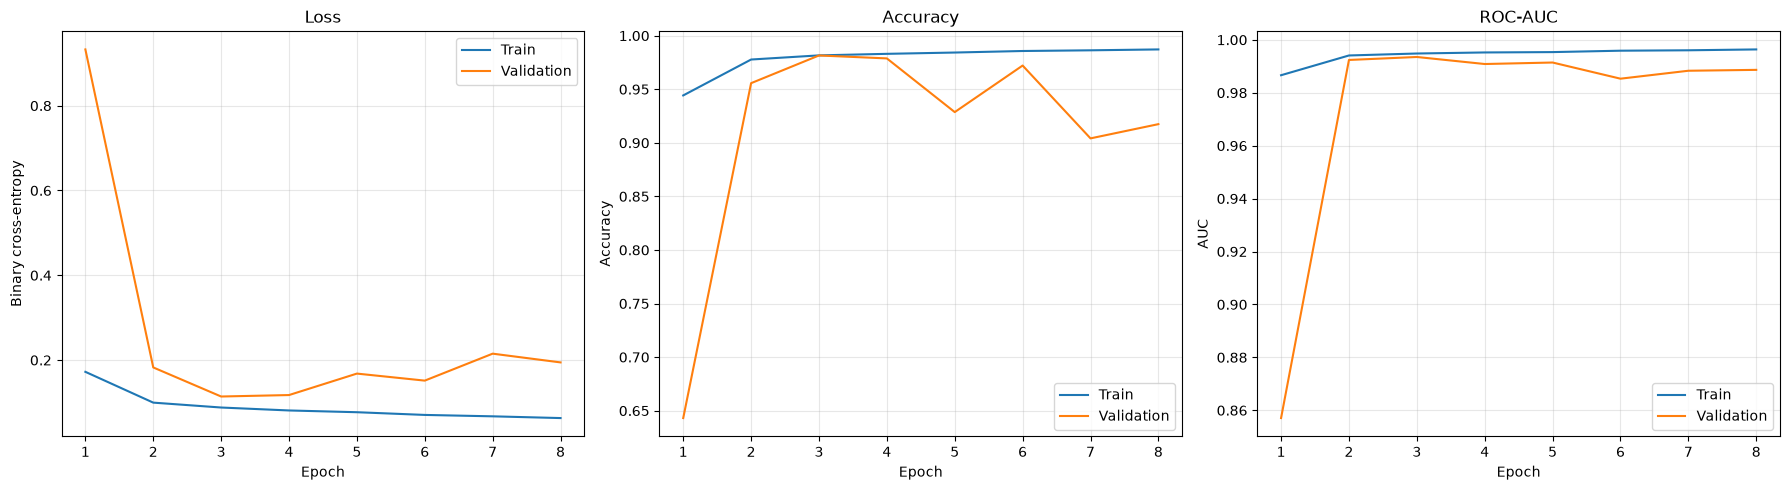

In [31]:
# Đường học giúp nhận diện underfit/overfit giữa train và validation
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
curve_specs = [
    ("loss", "val_loss", "Loss", "Binary cross-entropy"),
    ("accuracy", "val_accuracy", "Accuracy", "Accuracy"),
    ("auc", "val_auc", "ROC-AUC", "AUC")
]

epochs_ran = range(1, len(history.history["loss"]) + 1)
for ax, (train_key, val_key, title, ylabel) in zip(axes, curve_specs):
    ax.plot(epochs_ran, history.history[train_key], label="Train")
    ax.plot(epochs_ran, history.history[val_key], label="Validation")
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()


## 5. Hiệu chỉnh ngưỡng quyết định

Không dùng cố định ngưỡng 0.5. Notebook chọn ngưỡng làm **F1 lớn nhất trên validation set** từ đường Precision-Recall. F1 cân bằng precision và recall, phù hợp khi lớp Attack/Normal không cân bằng và false negative là rủi ro quan trọng. Test set không được dùng để chọn ngưỡng, vì làm vậy sẽ gây rò rỉ thông tin đánh giá.

> Giá trị `0.5327` trong ảnh kiến trúc chỉ là ví dụ minh họa. `BEST_THRESHOLD` dưới đây là giá trị thực nghiệm tính từ validation set của lần huấn luyện hiện tại.


In [32]:
val_probabilities = model.predict(
    X_val, batch_size=BATCH_SIZE, verbose=1
).ravel()

val_precision, val_recall, val_thresholds = precision_recall_curve(
    y_val, val_probabilities
)

# precision/recall dài hơn thresholds một phần tử; chỉ ghép các điểm có threshold
val_f1 = (
    2 * val_precision[:-1] * val_recall[:-1]
    / (val_precision[:-1] + val_recall[:-1] + 1e-12)
)
best_threshold_index = int(np.argmax(val_f1))
BEST_THRESHOLD = float(val_thresholds[best_threshold_index])

print("=== NGƯỠNG TỐI ƯU TRÊN VALIDATION ===")
print(f"BEST_THRESHOLD : {BEST_THRESHOLD:.6f}")
print(f"Precision      : {val_precision[best_threshold_index]:.4f}")
print(f"Recall         : {val_recall[best_threshold_index]:.4f}")
print(f"F1-score       : {val_f1[best_threshold_index]:.4f}")


104/104 ━━━━━━━━━━━━━━━━━━━━ 32s 305ms/step
=== NGƯỠNG TỐI ƯU TRÊN VALIDATION ===
BEST_THRESHOLD : 0.573164
Precision      : 0.9943
Recall         : 0.9774
F1-score       : 0.9858


## 6. Đánh giá trên Test Set

Test set chỉ được sử dụng một lần sau khi đã chọn mô hình và `BEST_THRESHOLD`. Ngoài ROC-AUC, cần xem Precision-Recall và đặc biệt là **recall của lớp Attack**, vì false negative khiến request tấn công lọt qua hệ thống thường nguy hiểm hơn false positive.


104/104 ━━━━━━━━━━━━━━━━━━━━ 36s 342ms/step
=== CLASSIFICATION REPORT — TEST SET ===
              precision    recall  f1-score   support

      Normal     0.9598    0.9900    0.9746      9495
      Attack     0.9943    0.9769    0.9856     17088

    accuracy                         0.9816     26583
   macro avg     0.9771    0.9835    0.9801     26583
weighted avg     0.9820    0.9816    0.9817     26583



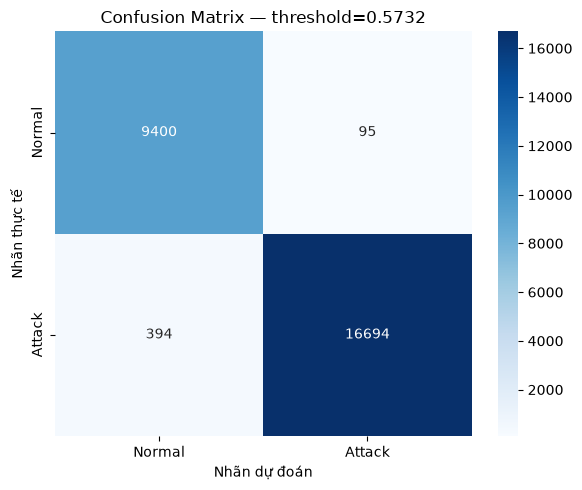

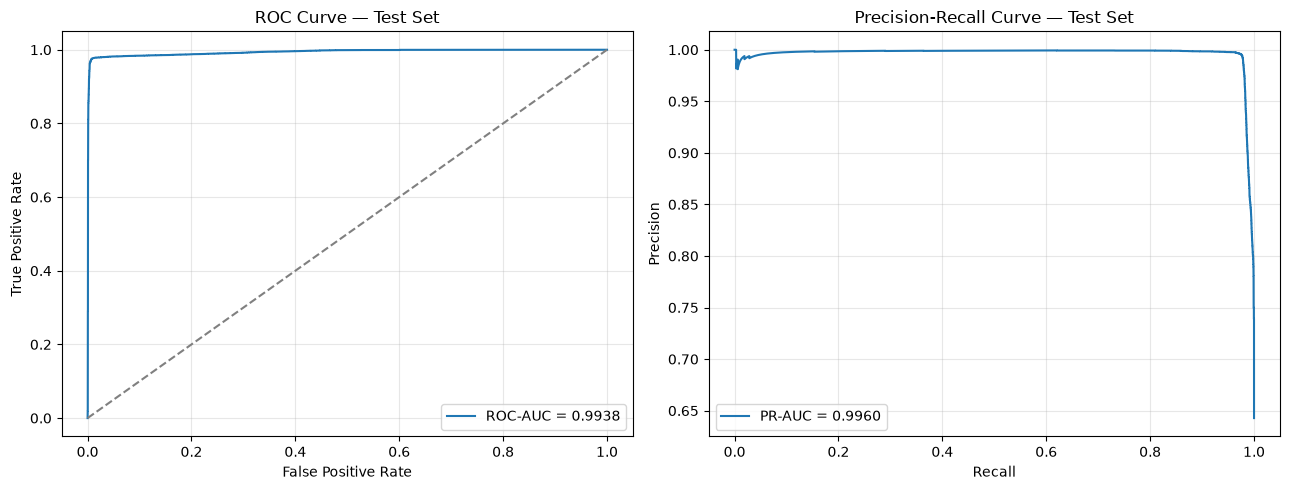


=== CHỈ SỐ TÓM TẮT TRÊN TEST ===
    best_threshold: 0.573164
          accuracy: 0.981605
  attack_precision: 0.994342
     attack_recall: 0.976943
         attack_f1: 0.985565
           roc_auc: 0.993790
            pr_auc: 0.996008
   false_positives: 95
   false_negatives: 394

=== NHẬN XÉT ===
Chưa thấy overfit nghiêm trọng: chênh lệch train/val AUC = 0.0013.
Recall Attack = 0.9769, đạt mức cao cho bài toán sàng lọc an ninh.


In [33]:
test_probabilities = model.predict(
    X_test, batch_size=BATCH_SIZE, verbose=1
).ravel()
test_predictions = (test_probabilities >= BEST_THRESHOLD).astype(int)

print("=== CLASSIFICATION REPORT — TEST SET ===")
print(classification_report(
    y_test,
    test_predictions,
    target_names=["Normal", "Attack"],
    digits=4,
    zero_division=0
))

report_dict = classification_report(
    y_test,
    test_predictions,
    target_names=["Normal", "Attack"],
    output_dict=True,
    zero_division=0
)
cm = confusion_matrix(y_test, test_predictions)
tn, fp, fn, tp = cm.ravel()

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal", "Attack"],
    yticklabels=["Normal", "Attack"]
)
plt.xlabel("Nhãn dự đoán")
plt.ylabel("Nhãn thực tế")
plt.title(f"Confusion Matrix — threshold={BEST_THRESHOLD:.4f}")
plt.tight_layout()
plt.show()

test_roc_auc = roc_auc_score(y_test, test_probabilities)
fpr, tpr, _ = roc_curve(y_test, test_probabilities)
test_precision_curve, test_recall_curve, _ = precision_recall_curve(
    y_test, test_probabilities
)
test_pr_auc = auc(test_recall_curve, test_precision_curve)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(fpr, tpr, label=f"ROC-AUC = {test_roc_auc:.4f}")
axes[0].plot([0, 1], [0, 1], "--", color="gray")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve — Test Set")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(
    test_recall_curve,
    test_precision_curve,
    label=f"PR-AUC = {test_pr_auc:.4f}"
)
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve — Test Set")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

test_metrics = {
    "best_threshold": BEST_THRESHOLD,
    "accuracy": report_dict["accuracy"],
    "attack_precision": report_dict["Attack"]["precision"],
    "attack_recall": report_dict["Attack"]["recall"],
    "attack_f1": report_dict["Attack"]["f1-score"],
    "roc_auc": test_roc_auc,
    "pr_auc": test_pr_auc,
    "false_positives": int(fp),
    "false_negatives": int(fn)
}

print("\n=== CHỈ SỐ TÓM TẮT TRÊN TEST ===")
for metric_name, metric_value in test_metrics.items():
    if isinstance(metric_value, float):
        print(f"{metric_name:>18}: {metric_value:.6f}")
    else:
        print(f"{metric_name:>18}: {metric_value}")

# Nhận xét tự động ngắn về overfit và rủi ro false negative
best_epoch = int(np.argmax(history.history["val_auc"]))
train_auc_at_best = history.history["auc"][best_epoch]
val_auc_at_best = history.history["val_auc"][best_epoch]
auc_gap = train_auc_at_best - val_auc_at_best
attack_recall = report_dict["Attack"]["recall"]

print("\n=== NHẬN XÉT ===")
if auc_gap > 0.05:
    print(f"Có dấu hiệu overfit: chênh lệch train/val AUC = {auc_gap:.4f}.")
else:
    print(f"Chưa thấy overfit nghiêm trọng: chênh lệch train/val AUC = {auc_gap:.4f}.")

if attack_recall >= 0.95:
    print(f"Recall Attack = {attack_recall:.4f}, đạt mức cao cho bài toán sàng lọc an ninh.")
else:
    print(
        f"Recall Attack = {attack_recall:.4f}; cần ưu tiên giảm {fn} false negative, "
        "có thể chọn ngưỡng thiên về recall hoặc bổ sung dữ liệu obfuscation."
    )


## 7. Lưu model và artifacts

Lưu model định dạng `.keras`, tokenizer bằng pickle và cấu hình tiền xử lý bằng JSON. File cấu hình chứa `MAX_LEN`, `VOCAB_SIZE`, `BEST_THRESHOLD` và mô tả normalization, giúp inference tái sử dụng đúng pipeline mà không cần train lại.

`json` là thư viện chuẩn Python; không phát sinh dependency mới.


In [34]:
import json

ARTIFACT_DIR = Path("artifacts")
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

MODEL_PATH = ARTIFACT_DIR / "xss_sqli_cnn_lstm.keras"
TOKENIZER_PATH = ARTIFACT_DIR / "char_tokenizer.pkl"
CONFIG_PATH = ARTIFACT_DIR / "preprocessing_config.json"

model.save(MODEL_PATH)

with TOKENIZER_PATH.open("wb") as file:
    pickle.dump(tokenizer, file)

artifact_config = {
    "max_len": int(MAX_LEN),
    "vocab_size": int(VOCAB_SIZE),
    "best_threshold": float(BEST_THRESHOLD),
    "tokenizer_level": "character",
    "lowercase": False,
    "decode_url_or_html": False,
    "normalization": "collapse_whitespace_and_strip"
}
with CONFIG_PATH.open("w", encoding="utf-8") as file:
    json.dump(artifact_config, file, ensure_ascii=False, indent=2)

print("Đã lưu artifacts:")
print(f"- Model     : {MODEL_PATH.resolve()}")
print(f"- Tokenizer : {TOKENIZER_PATH.resolve()}")
print(f"- Config    : {CONFIG_PATH.resolve()}")


Đã lưu artifacts:
- Model     : C:\Users\admin\Desktop\chal\artifacts\xss_sqli_cnn_lstm.keras
- Tokenizer : C:\Users\admin\Desktop\chal\artifacts\char_tokenizer.pkl
- Config    : C:\Users\admin\Desktop\chal\artifacts\preprocessing_config.json


## 8. Inference cho payload hoặc HTTP request mới

Cell dưới đây nạp lại artifacts từ ổ đĩa để chứng minh sản phẩm có thể dự đoán mà không train lại. Hàm `predict_payload()` áp dụng đúng `normalize_payload()`, tokenizer char-level, padding và `BEST_THRESHOLD` đã lưu.


In [35]:
# Nạp lại toàn bộ artifacts, mô phỏng một phiên inference độc lập
inference_model = tf.keras.models.load_model(MODEL_PATH)

with TOKENIZER_PATH.open("rb") as file:
    inference_tokenizer = pickle.load(file)

with CONFIG_PATH.open("r", encoding="utf-8") as file:
    inference_config = json.load(file)

INFERENCE_MAX_LEN = int(inference_config["max_len"])
INFERENCE_THRESHOLD = float(inference_config["best_threshold"])

def predict_payload(raw_text: str) -> dict:
    """Dự đoán một payload hoặc chuỗi HTTP request mới."""
    if not isinstance(raw_text, str):
        raise TypeError("raw_text phải là chuỗi str")

    normalized_text = normalize_payload(raw_text)
    if not normalized_text:
        raise ValueError("Payload rỗng sau khi chuẩn hóa")

    sequence = inference_tokenizer.texts_to_sequences([normalized_text])
    padded_sequence = pad_sequences(
        sequence,
        maxlen=INFERENCE_MAX_LEN,
        padding="post",
        truncating="post"
    )
    probability = float(inference_model.predict(padded_sequence, verbose=0)[0, 0])
    is_attack = probability >= INFERENCE_THRESHOLD

    return {
        "label": "Attack" if is_attack else "Normal",
        "probability": probability,
        "is_attack": bool(is_attack)
    }

# Sanity check: ví dụ obfuscation và request benign
sanity_samples = {
    "XSS URL-encoded": "GET /search?q=%3CsCrIpT%3Ealert%281%29%3C%2FsCrIpT%3E HTTP/1.1",
    "XSS HTML entity": "<img src=x onerror=&#x61;&#x6c;&#x65;&#x72;&#x74;(1)>",
    "SQLi case-mixing": "GET /item?id=1%27+UnIoN+SeLeCt+username,password+FrOm+users-- HTTP/1.1",
    "SQLi encoded quote": "username=admin&password=%27%20OR%20%271%27%3D%271%27--",
    "Benign search": "GET /search?q=deep+learning+security HTTP/1.1",
    "Benign form": "name=Nguyen+Van+A&email=student%40example.com&age=20"
}

for sample_name, sample_text in sanity_samples.items():
    prediction = predict_payload(sample_text)
    print(
        f"{sample_name:>20} | {prediction['label']:<6} | "
        f"p={prediction['probability']:.6f}"
    )


     XSS URL-encoded | Attack | p=0.999512
     XSS HTML entity | Attack | p=0.998718
    SQLi case-mixing | Attack | p=0.911304
  SQLi encoded quote | Attack | p=0.999938
       Benign search | Normal | p=0.371103
         Benign form | Attack | p=0.703028


## 9. Tóm tắt kết quả và quyết định thiết kế

### Review Giai đoạn 1

- Không có data leakage trực tiếp qua tokenizer hoặc `MAX_LEN`: cả hai chỉ được fit/tính trên train.
- Tokenizer hiện đã được lưu ở Mục 7.
- Các hạn chế cần nêu trong báo cáo: CSIC chứa nhiều loại request bất thường ngoài XSS/SQLi; exact dedup chưa loại near-duplicate/template leakage; cap 512 truncate khoảng 26.5% mẫu và tỷ lệ truncate khác nhau theo nhãn.

### Quyết định thiết kế chính

- Giữ URL encoding, HTML entity và chữ hoa/thường; dùng tokenizer char-level để bảo tồn tín hiệu obfuscation.
- CNN và LSTM một chiều chạy song song độc lập từ cùng Embedding 64 chiều, sau đó hợp nhất bằng Concatenate.
- Dùng class weight, EarlyStopping và regularization để giảm thiên lệch lớp và overfit.
- Chọn `BEST_THRESHOLD` bằng F1 trên validation; test set không tham gia tuning.

### Bộ chỉ số cuối trên Test Set

Sau khi chạy notebook, Mục 6 in và lưu trong `test_metrics` các giá trị: **Accuracy, Precision/Recall/F1 của lớp Attack, ROC-AUC, PR-AUC, false positives, false negatives và BEST_THRESHOLD**. Các giá trị này là kết quả thực nghiệm cuối cần chép nguyên vẹn vào báo cáo; không điền số giả định trước khi mô hình được huấn luyện.
